In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Подготовка

In [2]:
df_sessions = pd.read_csv('ga_sessions.csv', low_memory=False)
df_sessions

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.1640159304,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,NaN,NaN,VlqBmecIOXWjCWUmQkLd,desktop,Windows,NaN,NaN,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.1622007305,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.1636979515,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.1638189272,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x851,Chrome,Russia,Chelyabinsk


In [3]:
df_sessions.isnull().sum().sort_values()

session_id                        0
device_browser                    0
device_screen_resolution          0
device_category                   0
geo_country                       0
utm_medium                        0
geo_city                          0
visit_number                      0
visit_time                        0
visit_date                        0
client_id                         0
utm_source                       97
utm_campaign                 219603
utm_adcontent                335615
device_brand                 367178
device_os                   1070138
utm_keyword                 1082061
device_model                1843704
dtype: int64

In [4]:
df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [5]:
df_sessions.duplicated().sum()

0

In [6]:
df_hits = pd.read_csv('ga_hits.csv', low_memory=False)
df_hits

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
15726465,6866159858916559617.1640270865.1640270865,2021-12-23,810589.0,43,event,NaN,sberauto.com/cars/all/toyota/fortuner/24cb5af2...,quiz,quiz_show,NaN,NaN
15726466,7310304587364460692.1640261783.1640261783,2021-12-23,904927.0,40,event,NaN,sberauto.com/cars/all/mercedes-benz/gla-klasse...,quiz,quiz_show,NaN,NaN
15726467,8013702685784312179.1640270195.1640270195,2021-12-23,2172865.0,43,event,NaN,sberauto.com/cars/all/toyota/alphard/2ebe4871?...,quiz,quiz_show,NaN,NaN
15726468,8021505554734405918.1640257821.1640257821,2021-12-23,713325.0,45,event,NaN,sberauto.com/cars/all/bmw/x3/6a660f0a?rental_p...,quiz,quiz_show,NaN,NaN


In [7]:
df_hits.isnull().sum().sort_values()

session_id               0
hit_date                 0
hit_number               0
hit_type                 0
hit_page_path            0
event_category           0
event_action             0
event_label        3760184
hit_referer        6274804
hit_time           9160322
event_value       15726470
dtype: int64

In [8]:
df_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


In [9]:
df_hits.duplicated().sum()

0

данные уже очищены, дополнительная очистка не нужна

1 GA Sessions (ga_sessions.pkl) 

Одна строка = один визит на сайт. 

Описание атрибутов: 

session_id — ID визита; 

client_id — ID посетителя; 

visit_date — дата визита; 

visit_time — время визита; 

visit_number — порядковый номер визита клиента; 

utm_source — канал привлечения; 

utm_medium — тип привлечения; 

utm_cam paign — рекламная кампания; 

utm_key word — ключевое слово; 

device_category — тип устройства; 

device_os — ОС устройства; 

device_brand — марка устройства; 

device_model — модель устройства; 

device_screen_resolution — разрешение экрана  

evice_brand — марка устройства; 

device_model — модель устройства; 

device_screen_resolution — разрешение экрана; 

device_browser — браузер; 

geo_country — страна; 

geo_city — город. 

1 GA Hits (ga_hits.pkl) 

Одна строка = одно событие в рамках одного визита на сайт.

Описание атрибутов: 

session_id — ID визита; 

hit_date — дата события; 

hit_time — время события; 

hit_number — порядковый номер события в рамках сессии; 

hit_ty pe — тип события; 

hit_re ferer — источник события; 

hit_ page_path — страница события; 

event_category — тип действия; 

event_action — действие; 

event_label — тег действия; 

event_value — значение результата действия.

в ga_sessions лежат признаки источника трафика, устройцства и гео, в ga_hits лежат поведение пользователя внутри визита. связка этих данных идет по session_id. данные реальные и с определенным количеством шума. в некоторых столбцах много пропусков. целевые действия находятся в таблице ga_hits, колонки event_category, event_action

## Разведка

In [10]:
df_sessions['visit_date'] = pd.to_datetime(df_sessions['visit_date'])
df_hits['hit_date'] = pd.to_datetime(df_hits['hit_date'])

In [11]:
df_sessions['visit_datetime'] = pd.to_datetime(
    df_sessions['visit_date'].astype(str) + ' ' + df_sessions['visit_time']
)

In [12]:
df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 19 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                object        
 1   client_id                 object        
 2   visit_date                datetime64[ns]
 3   visit_time                object        
 4   visit_number              int64         
 5   utm_source                object        
 6   utm_medium                object        
 7   utm_campaign              object        
 8   utm_adcontent             object        
 9   utm_keyword               object        
 10  device_category           object        
 11  device_os                 object        
 12  device_brand              object        
 13  device_model              object        
 14  device_screen_resolution  object        
 15  device_browser            object        
 16  geo_country               object        
 17  geo_city

In [13]:
df_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   session_id      object        
 1   hit_date        datetime64[ns]
 2   hit_time        float64       
 3   hit_number      int64         
 4   hit_type        object        
 5   hit_referer     object        
 6   hit_page_path   object        
 7   event_category  object        
 8   event_action    object        
 9   event_label     object        
 10  event_value     float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 1.3+ GB


In [14]:
sessions_na = df_sessions.isna().mean().sort_values(ascending=False)
hits_na = df_hits.isna().mean().sort_values(ascending=False)

In [15]:
sessions_na

device_model                0.991216
utm_keyword                 0.581740
device_os                   0.575330
device_brand                0.197403
utm_adcontent               0.180434
utm_campaign                0.118063
utm_source                  0.000052
geo_city                    0.000000
geo_country                 0.000000
device_browser              0.000000
device_screen_resolution    0.000000
session_id                  0.000000
device_category             0.000000
client_id                   0.000000
utm_medium                  0.000000
visit_number                0.000000
visit_time                  0.000000
visit_date                  0.000000
visit_datetime              0.000000
dtype: float64

In [16]:
hits_na

event_value       1.000000
hit_time          0.582478
hit_referer       0.398996
event_label       0.239099
session_id        0.000000
hit_date          0.000000
hit_number        0.000000
hit_type          0.000000
hit_page_path     0.000000
event_category    0.000000
event_action      0.000000
dtype: float64

In [17]:
df_sessions = df_sessions.drop(columns=['device_model'])

много пропусков, поэтому удаляем

In [18]:
cols_fill_unknown = [
    'utm_keyword',
    'device_os',
    'device_brand',
    'utm_adcontent',
    'utm_campaign'
]

for col in cols_fill_unknown:
    df_sessions[col] = df_sessions[col].fillna('unknown')

In [19]:
df_hits = df_hits.drop(columns=[
    'event_value',
    'hit_time',
    'hit_referer',
    'event_label'
])

удаляем эти столбцы - эти признаки не несут ценности для ML.

In [20]:
categorical_cols = [
    'utm_source',
    'utm_medium',
    'utm_campaign',
    'utm_adcontent',
    'utm_keyword',
    'device_category',
    'device_os',
    'device_brand',
    'device_browser',
    'geo_country',
    'geo_city'
]

In [21]:
for col in categorical_cols:
    df_sessions[col] = df_sessions[col].astype('category')

переводим стоблцы из categorical_cols в категориальный тип

In [22]:
df_sessions['client_id'] = df_sessions['client_id'].astype(str)
df_sessions['session_id'] = df_sessions['session_id'].astype(str)

df_hits['session_id'] = df_hits['session_id'].astype(str)

In [23]:
df_sessions.dtypes

session_id                          object
client_id                           object
visit_date                  datetime64[ns]
visit_time                          object
visit_number                         int64
utm_source                        category
utm_medium                        category
utm_campaign                      category
utm_adcontent                     category
utm_keyword                       category
device_category                   category
device_os                         category
device_brand                      category
device_screen_resolution            object
device_browser                    category
geo_country                       category
geo_city                          category
visit_datetime              datetime64[ns]
dtype: object

In [24]:
df_hits.dtypes

session_id                object
hit_date          datetime64[ns]
hit_number                 int64
hit_type                  object
hit_page_path             object
event_category            object
event_action              object
dtype: object

распределение ключевых признаков:

In [25]:
# источники трафика
df_sessions['utm_source'].value_counts().head(20)

ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
vFcAhRxLfOWKhvxjELkx     24413
PlbkrSYoHuZBWfYjYnfw     20792
hTjLvqNxGggkGnxSCaTm     14598
gDBGzjFKYabGgSPZvrDH     13565
fgymSoTvjKPEgaIJqsiH      9625
geDcueAOghDzHkGMmdOq      8680
ISrKoXQCxqqYvAZICvjs      8633
nSReTmyFtbSjlPrTKoaX      7285
SzZERoLMmrEUEhDaYcyN      6828
eLzNJHzPelJpEyBwMrKo      5386
Name: utm_source, dtype: int64

In [26]:
# тип устройства
df_sessions['device_category'].value_counts()

mobile     1474871
desktop     366863
tablet       18308
Name: device_category, dtype: int64

80%  - мобильный трафик

In [27]:
# браузеры
df_sessions['device_browser'].value_counts().head(20)

Chrome                              1013436
Safari                               478562
YaBrowser                            133311
Safari (in-app)                       69912
Android Webview                       55369
Samsung Internet                      47309
Opera                                 26817
Firefox                               16588
Edge                                  16065
UC Browser                              871
Android Runtime                         392
Mozilla Compatible Agent                362
[FBAN                                   269
Instagram 208.0.0.32.135 Android        140
Instagram 209.0.0.21.119 Android        111
MRCHROME                                 77
Android Browser                          49
Puffin                                   45
Opera Mini                               45
Internet Explorer                        36
Name: device_browser, dtype: int64

топ-3 браузера дают 85% трафика

In [28]:
# города
df_sessions['geo_city'].value_counts().head(10)

Moscow              805329
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Kazan                29531
Samara               24992
Nizhny Novgorod      22227
Ufa                  21679
Novosibirsk          21568
Name: geo_city, dtype: int64

почти весь траифк из РФ - Москва и Питер

целевые события

In [29]:
df_hits['event_action'].value_counts().head(30)

view_card                             3558985
view_new_card                         3551009
sub_landing                           1798117
go_to_car_card                         973666
sub_view_cars_click                    791515
search_form_region                     512069
search_form_search_btn                 433748
sap_search_form_cost_to                356596
showed_number_ads                      326274
pagination_click                       248944
search_form_mark_select                222652
quiz_show                              214037
search_form_model_select               211890
sap_search_form_cost_from              188129
photos_all                             181493
search_form_search_car_type_select     174877
photos                                 158543
sub_car_page                           130310
view_more_click                        109971
search_kpp                              79465
sub_header_link_click                   79192
proactive invitation shown        

In [30]:
df_hits['event_category'].value_counts().head(30)

card_web                     7456998
search_form                  2423605
sub_page_view                1986074
sub_button_click             1073471
listing_ads                  1040468
cars                          358915
sap_search_form               356596
quiz                          263134
auth                          189373
sap_search__form              188129
jivosite                       88443
chat                           85007
ad_banner                      40441
offers                         31218
navigation                     27075
footer                         20297
sub_submit                     18495
greenday_sub_button_click      15425
main_banners                   14142
profile_menu                   13879
scrolling_main_page            12160
active_invitation               8478
header                          3531
my_idea                         2319
greenday_listing_ads            1792
main_services                   1464
phone                           1212
c

In [31]:
df_hits[df_hits['event_category']=='sub_submit'].head()

,session_id,hit_date,hit_number,hit_type,hit_page_path,event_category,event_action
4016,2744563715298057088.1640258436.1640258436,2021-12-23,81,event,sberauto.com/cars/all/kia/rio/fee33fe6?utm_sou...,sub_submit,sub_submit_success
4045,3087297479839089634.1640268774.1640268774,2021-12-23,22,event,sberauto.com/cars/all/skoda/rapid/bf24b977?utm...,sub_submit,sub_submit_success
4046,3156966333326004302.1640206419.1640206800,2021-12-23,63,event,sberauto.com/cars/all/skoda/rapid/bf24b977?utm...,sub_submit,sub_submit_success
4047,3750243879753098158.1640272208.1640272208,2021-12-23,20,event,sberauto.com/cars/all/nissan/x-trail/0744675f?...,sub_submit,sub_submit_success
4048,7518333712042258254.1640258901.1640258901,2021-12-23,16,event,sberauto.com/cars/all/mercedes-benz/gla-klasse...,sub_submit,sub_submit_success


In [32]:
df_hits[df_hits['event_action']=='sub_submit_success'].head()

,session_id,hit_date,hit_number,hit_type,hit_page_path,event_category,event_action
4016,2744563715298057088.1640258436.1640258436,2021-12-23,81,event,sberauto.com/cars/all/kia/rio/fee33fe6?utm_sou...,sub_submit,sub_submit_success
4045,3087297479839089634.1640268774.1640268774,2021-12-23,22,event,sberauto.com/cars/all/skoda/rapid/bf24b977?utm...,sub_submit,sub_submit_success
4046,3156966333326004302.1640206419.1640206800,2021-12-23,63,event,sberauto.com/cars/all/skoda/rapid/bf24b977?utm...,sub_submit,sub_submit_success
4047,3750243879753098158.1640272208.1640272208,2021-12-23,20,event,sberauto.com/cars/all/nissan/x-trail/0744675f?...,sub_submit,sub_submit_success
4048,7518333712042258254.1640258901.1640258901,2021-12-23,16,event,sberauto.com/cars/all/mercedes-benz/gla-klasse...,sub_submit,sub_submit_success


In [33]:
target_events = ['sub_submit_success']

df_hits['target_event'] = df_hits['event_action'].isin(target_events).astype(int)

target_sessions = (
    df_hits.groupby('session_id')['target_event']
    .max()
    .reset_index()
)

In [34]:
target = (
    df_hits.groupby('session_id')['target_event']
    .max()
    .reset_index()
)

In [35]:
df = df_sessions.merge(target, on='session_id', how='left')
df['target_event'] = df['target_event'].fillna(0)

In [36]:
df['target_event'].mean()

0.008542817850349617

Text(0.5, 1.0, 'Target distribution')

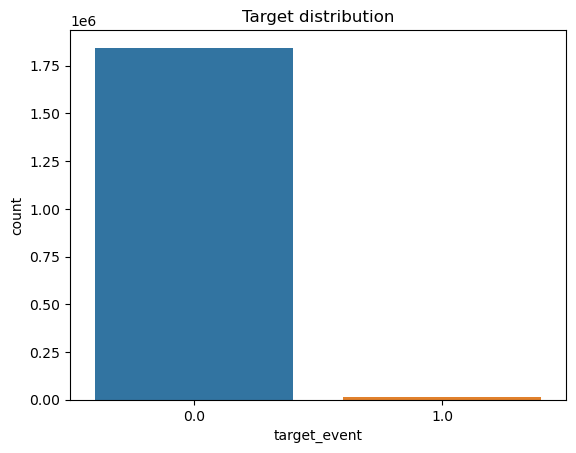

In [37]:
# распределение target
df['target_event'].value_counts(normalize=True)
sns.countplot(x='target_event', data=df)
plt.title('Target distribution')

Text(0.5, 1.0, 'Conversion by source')

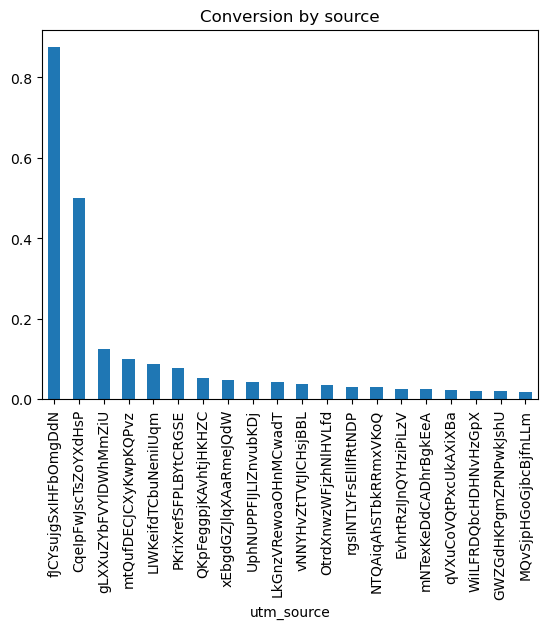

In [38]:
# конверсия по каналам
conversion_source = df.groupby('utm_source')['target_event'].mean().sort_values(ascending=False).head(20)
conversion_source.plot(kind='bar')
plt.title('Conversion by source')

In [39]:
# конверсия по устройствам
df.groupby('device_category')['target_event'].mean()

device_category
desktop    0.009224
mobile     0.008403
tablet     0.006172
Name: target_event, dtype: float64

In [40]:
# конверсия по браузерам
df.groupby('device_browser')['target_event'].mean().sort_values(ascending=False).head(15)

device_browser
Edge                        0.010458
Android Webview             0.009464
YaBrowser                   0.009362
Safari                      0.009259
Firefox                     0.008922
Chrome                      0.008485
Samsung Internet            0.005665
Safari (in-app)             0.005307
Opera                       0.004848
UC Browser                  0.003444
Maxthon                     0.000000
MT6735_TD                   0.000000
MRCHROME                    0.000000
Mozilla                     0.000000
Mozilla Compatible Agent    0.000000
Name: target_event, dtype: float64

<AxesSubplot:>

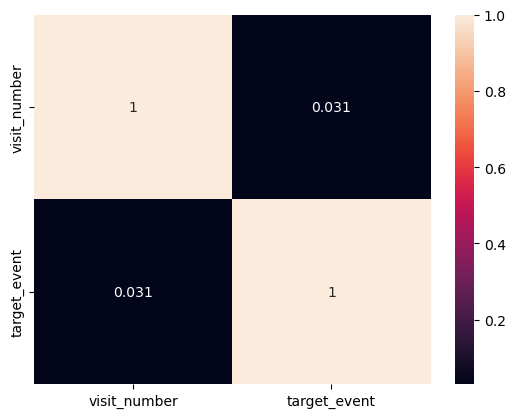

In [41]:
# Heatmap корреляций
num_cols = ['visit_number', 'target_event']

sns.heatmap(df[num_cols].corr(), annot=True)

In [44]:
df_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 8 columns):
 #   Column          Dtype         
---  ------          -----         
 0   session_id      object        
 1   hit_date        datetime64[ns]
 2   hit_number      int64         
 3   hit_type        object        
 4   hit_page_path   object        
 5   event_category  object        
 6   event_action    object        
 7   target_event    int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(5)
memory usage: 899.9+ MB


Вывод по целевым событиям - 

event_action

Топ событий:

view_card
view_new_card
sub_landing
go_to_car_card
sub_view_cars_click
...

event_category

card_web
search_form
sub_page_view
sub_button_click
listing_ads
...

Типичный путь пользователя:

view_card
→ view_new_card
→ go_to_car_card
→ sub_landing
→ sub_submit

Конверсия происходит на sub_submit_success.

Поэтому целевое событие:

event_action == 'sub_submit_success'

Финальный target

target = 1
если session содержит событие sub_submit

Это событие соответствует конверсии, т.е. отправке заявки на сервис «СберАвтоподписка».

Проведён разведочный анализ данных. Было выявлено, что целевое действие совершается примерно в 0.85% сессий, что говорит о сильном дисбалансе классов. Конверсия зависит от источника трафика, типа устройства и браузера пользователя.

In [42]:
df_hits['target_event'] = (df_hits['event_action'] == 'sub_submit_success').astype(int)